In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'rfm_scores.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/RFM_Customer_Segmentation/Data/rfm_scores.csv


In [61]:
rfm = pd.read_csv("/content/drive/MyDrive/RFM_Customer_Segmentation/Data/rfm_scores.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


### **Set 1: Define Segments**

In [62]:
# We assign segments based on R and F scores
# M Score supoorts but R and F are the strongest signals

def assign_segment(row):
  r = row["R_Score"]
  f = row["F_Score"]
  m = row["M_Score"]


  if r >= 4 and f >= 4 and m >= 4:   # Best Customers --
    return "Champion"
  elif r >= 3 and f >= 3 and m >= 3: # Good Customers --
    return " Loyal Customer"
  elif r >= 4 and f <= 2:            # Bought Recently but not many times yet
    return "New Customer"
  elif r >= 3 and f >= 2:            # Recent + buying more than once - could become loyal
    return "Potential Loyalist"
  elif r <= 2 and f >= 3:            # Used to buy often but stooped coming back
    return "At Risk"
  else:                              # Low scores everywhere -- gone off
    return "Lost"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

In [63]:
rfm["Segment"].value_counts()

,count
Segment,
Lost,1229
Champion,957
Loyal Customer,764
At Risk,643
Potential Loyalist,426
New Customer,319


### **Step 2: Segment Summary**

In [64]:
segment_summary = rfm.groupby("Segment").agg(
    Total_Customers = ("CustomerID", 'count'),
    Avg_Recency = ("Recency", "mean"),
    Avg_Frequency = ("Frequency", "mean"),
    Avg_Monetary = ("Monetary", "mean")
).round(2).reset_index()

segment_summary

,Segment,Total_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,Loyal Customer,764,35.69,4.12,1827.90
1,At Risk,643,152.84,3.40,1241.14
2,Champion,957,12.82,11.12,6051.87
3,Lost,1229,196.02,1.09,477.68
4,New Customer,319,18.52,1.24,455.23
5,Potential Loyalist,426,39.43,1.93,396.06


### **Set 3: Visualize Segments**

In [65]:
# Chart 1 - Customer count per segment

segment_counts = rfm["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Count"]

segment_counts

,Segment,Count
0,Lost,1229
1,Champion,957
2,Loyal Customer,764
3,At Risk,643
4,Potential Loyalist,426
5,New Customer,319


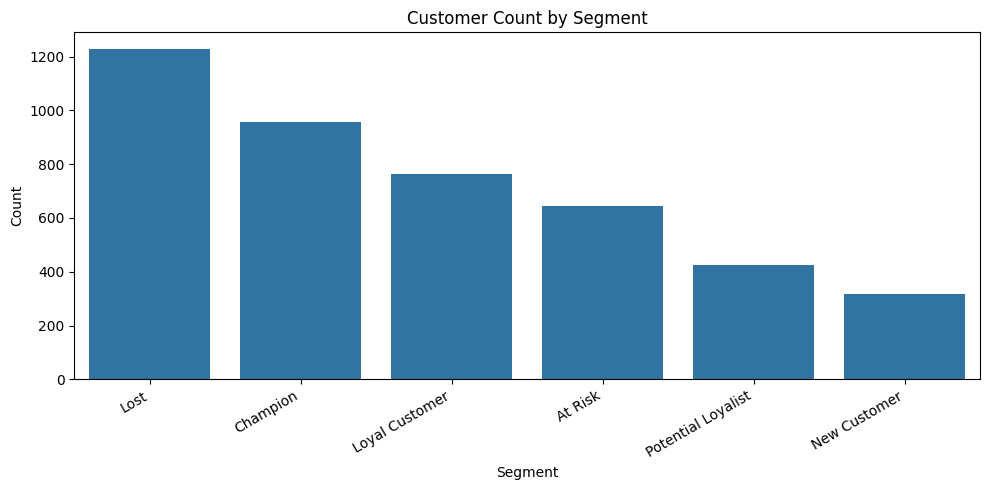

In [66]:
plt.figure(figsize=(10, 5))
sns.barplot(data=segment_counts, x="Segment", y="Count")
plt.title("Customer Count by Segment")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.savefig("/content/08_segment_revenue.png", dpi=150)
plt.show()

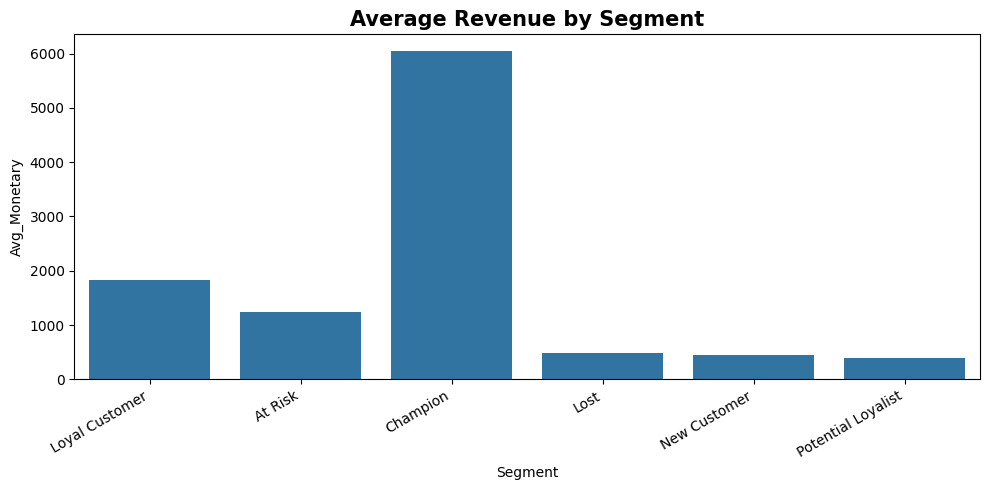

In [67]:
# Chart 2 - Average Revenue Per Segment

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary, x="Segment", y="Avg_Monetary")
plt.title("Average Revenue by Segment", fontsize=15, fontweight="bold")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.savefig("/content/09_segment_revenue.png", dpi=150)
plt.show()

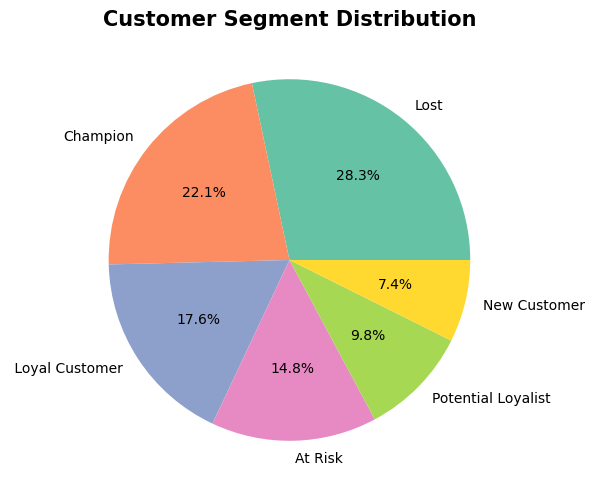

In [68]:
# Chart 3 Pie Chart of Segment Distribution

plt.figure(figsize=(6, 6))
plt.pie(
    segment_counts["Count"],
    labels=segment_counts["Segment"],
    autopct= '%1.1f%%',
    colors=sns.color_palette('Set2', len(segment_counts))
)
plt.title("Customer Segment Distribution", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/10_segment_pie.png", dpi=150)
plt.show()

In [69]:
from google.colab import files

# Save segmented data
rfm.to_csv('/content/rfm_segmented.csv', index=False)
files.download('/content/rfm_segmented.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Business Insights from Segmentation**

In [70]:
# Segment Size

rfm["Segment"].value_counts()

,count
Segment,
Lost,1229
Champion,957
Loyal Customer,764
At Risk,643
Potential Loyalist,426
New Customer,319


In [71]:
# Revenue Contribution for Per Segment

revenue_by_segment = (rfm.groupby("Segment")["Monetary"]
                      .sum()
                      .sort_values(ascending=False))

revenue_by_segment

,Monetary
Segment,
Champion,5791640.74
Loyal Customer,1396513.16
At Risk,798052.51
Lost,587062.85
Potential Loyalist,168719.89
New Customer,145219.74


In [78]:
# What % of total revenue does each segment contribute

revenue_share = (revenue_by_segment / revenue_by_segment.sum() * 100).round(2)
revenue_share

,Monetary
Segment,
Champion,65.17
Loyal Customer,15.71
At Risk,8.98
Lost,6.61
Potential Loyalist,1.90
New Customer,1.63


In [73]:
# Business Overivew Numbers

total_revenue = rfm["Monetary"].sum()
total_customers = rfm["CustomerID"].nunique()
avg_spend = rfm["Monetary"].mean()

print("=== Business Overview ===")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Customers: {total_customers:,.2f}")
print(f"Average Spend: {avg_spend:,.2f}")

=== Business Overview ===
Total Revenue: 8,887,208.89
Total Customers: 4,338.00
Average Spend: 2,048.69


In [74]:
# Segment Numbers

print("=== Segment Counts ===")
rfm["Segment"].value_counts()

=== Segment Counts ===


,count
Segment,
Lost,1229
Champion,957
Loyal Customer,764
At Risk,643
Potential Loyalist,426
New Customer,319


In [75]:
print("=== Average Spend by Segment ===")
print(rfm.groupby("Segment")["Monetary"].mean())

=== Average Spend by Segment ===
Segment
 Loyal Customer       1827.896806
At Risk               1241.139207
Champion              6051.871202
Lost                   477.675224
New Customer           455.234295
Potential Loyalist     396.056080
Name: Monetary, dtype: float64
